# Домашнее задание: Построение RAG-системы с трансформерными декодерами

В этом домашнем задании вы закрепите знания о трансформерных декодерах и архитектуре Retrieval-Augmented Generation (RAG). Мы пройдем путь от простого полнотекстового поиска до продвинутого пайплайна с переранжированием и использованием LLM для генерации ответа.

## Практический бизнес-кейс: "ВикиПомощник" для контент-агентства

Крупное контент-агентство ежедневно создает сотни экспертных статей, аналитических отчетов и образовательных материалов. Редакторы агентства постоянно работают с огромным объемом энциклопедической информации. Сейчас процесс проверки фактов и поиска нужных деталей в справочниках занимает у них до 30% рабочего времени. Ручной поиск неэффективен, а использование публичных LLM без контекста часто приводит к галлюцинациям в статьях.

Руководство агентства поставило задачу разработать внутренний инструмент "ВикиПомощник". Это RAG-система, которая должна принимать вопрос редактора, мгновенно находить наиболее релевантные абзацы в проверенной базе знаний (русскоязычной Википедии) и формировать точный, лаконичный ответ на основе найденного контекста.

Ожидаемый результат внедрения ML-решения — сокращение времени на фактчекинг в 3 раза и полное устранение фактологических ошибок в выпускаемых материалах за счет опоры на доверенные источники.

## Рекомендации по выполнению в Google Colab

Для выполнения заданий, связанных с нейросетевыми моделями (BGE-M3, BGE-Reranker, Qwen3.5-9B), настоятельно рекомендуется использовать GPU.
1. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения`.
2. В поле `Аппаратный ускоритель` выберите `T4 GPU`.

**Решение проблемы нехватки памяти (CUDA Out of Memory):**
Если вы столкнулись с ошибкой `CUDA out of memory`, попробуйте следующие шаги:
- Уменьшите размер батча (например, с 32 до 16 или 8) при получении эмбеддингов.
- Ограничьте максимальную длину последовательности токенов (`max_length`).
- Перезапустите среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`).
- В коде можно использовать принудительную очистку кэша:
```python
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
```

Не забудьте сохранить копию ноутбука на свой Google Drive перед началом работы (`Файл` -> `Сохранить копию на Google Диск`).

## Таблица распределения баллов

| Блок | Задание | Баллы |
|---|---|---|
| **Часть 1. Стандартное ДЗ** | | **50** |
| 1 | Загрузка и подготовка данных (SberQuAD) | 8 |
| 2 | Полнотекстовый поиск (BM25) | 10 |
| 3 | Семантический поиск (BGE-M3) | 12 |
| 4 | Оценка качества: BM25 vs Семантика | 8 |
| 5 | RAG с декодером (Qwen3.5-9B) | 7 |
| 6 | Оценка стоимости запросов | 5 |
| **Часть 2. Продвинутое ДЗ** | | **50** |
| 7 | Гибридный поиск (RRF) | 10 |
| 8 | Переранжирование (Cross-Encoder) | 12 |
| 9 | Полный пайплайн с переранжированием и LLM | 8 |
| 10 | Сравнительный анализ всех стратегий и замер скорости | 10 |
| 11 | Расширенная оценка стоимости запросов | 5 |
| 12 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [ ]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 96.7 MB/s eta 0:00:00


## Блок 0: Формализация задачи

Прежде чем писать код, давайте формализуем нашу бизнес-задачу в терминах машинного обучения.
Бизнес-задача: Автоматизировать поиск фактов в базе знаний и формирование ответов на вопросы редакторов.
ML-задача: Построение пайплайна информационного поиска (Information Retrieval) и генерации текста (Text Generation).

Для оценки качества поиска мы будем использовать две метрики:
1. **Recall@K (Полнота)**: Доля запросов, для которых правильный ответ (ground truth) содержится хотя бы в одном из K найденных документов. Эта метрика критически важна для RAG, так как если нужной информации нет в контексте, LLM не сможет дать правильный ответ (или сгаллюцинирует).
2. **MRR@K (Mean Reciprocal Rank)**: Оценивает позицию первого релевантного документа в выдаче. Чем выше нужный документ, тем лучше, так как LLM обращают больше внимания на начало контекста (lost in the middle).

В RAG системах Recall обычно важнее Precision (точности), поскольку LLM способны отфильтровать нерелевантный шум в контексте, но не могут выдумать верный факт, если его вообще не передали в промпте.

---
# Часть 1. Стандартное ДЗ (50 баллов)


### Задание 1. Загрузка и подготовка данных (8 баллов)

Мы будем использовать датасет `kuznetsoffandrey/sberquad` — русскоязычный аналог популярного датасета SQuAD, собранный Сбером на основе статей Википедии.
Он содержит пары "контекст - вопрос - ответ".
В RAG системе уникальные тексты из поля `context` станут нашей базой знаний (корпусом документов), `question` — запросами пользователей, а `answers` мы будем использовать для автоматической оценки качества поиска.

**Что нужно сделать:**
1. Выполните предоставленный код загрузки датасета.
2. Напишите код для извлечения всех уникальных текстов из поля `context`. Это будет наш корпус документов. Сохраните их в список `corpus`.
3. Сформируйте словарь соответствия: `doc_id` -> `text`.
4. Подготовьте тестовую выборку: выберите 200 случайных вопросов из датасета. Для каждого вопроса сохраните сам текст вопроса и правильный ответ (из `answers['text'][0]`).
5. В комментариях кратко объясните, почему важно дедуплицировать контексты при создании базы знаний.


In [1]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn

from datasets import load_dataset
import pandas as pd
import numpy as np
import random

# Загрузка датасета (используем только validation split для скорости)
print("Загрузка датасета SberQuAD...")
dataset = load_dataset("kuznetsoffandrey/sberquad", split="validation")
df = pd.DataFrame(dataset)
print(f"Загружено {len(df)} записей.")


print("\n")

print("Исходный датасет (df):")
print(f"  Количество записей: {len(df)}")
print(f"  Количество столбцов: {len(df.columns)}")
print(f"  Пример столбцов: {df.columns.tolist()}")
# print(f"  Вывод:\n{df}")
print("\n")






# === ВАШ КОД ЗДЕСЬ ===
# 1. Извлеките уникальные контексты в список corpus
corpus = list(df['context'].unique())


print("\nКорпус (уникальные контексты):")
print(f"  Количество документов: {len(corpus)}")
print(f"  Средняя длина документа: {sum(len(t) for t in corpus) / len(corpus):.0f} символов")

print("\n")


# 2. Создайте словарь doc_id -> text (индексы от 0 до len(corpus)-1)
corpus_dict = {idx: text for idx, text in enumerate(corpus)}


# 3. Подготовьте 200 случайных тестовых вопросов
# Формат test_queries: список словарей [{'question': text, 'ground_truth': text}]



random.seed(501)  # фиксируем seed для воспроизводимости
sample_indices = random.sample(range(len(df)), 200)

# print(f"  sample_indices =  {sample_indices}")
# print("\n\n")



test_queries = []
for idx in sample_indices:
    row = df.iloc[idx]
    question = row['question']
    # answers — это словарь, берём первый ответ из списка
    ground_truth = row['answers']['text'][0]
    test_queries.append({'question': question, 'ground_truth': ground_truth})






print("\nТестовая выборка (test_queries):")
print(f"  Количество запросов: {len(test_queries)}")
print(f"  Пример вопроса: {test_queries[0]['question']}")
print(f"  Пример правильного ответа: {test_queries[0]['ground_truth']}")




# Сохранение corpus в текстовый файл (по одному документу на строку)
with open('corpus.txt', 'w', encoding='utf-8') as f:
    for doc in corpus:
        f.write(doc + '\n')
print("corpus сохранён в файл 'corpus.txt'")

# Сохранение corpus_dict в формате JSON (словарь doc_id -> text)
import json
with open('corpus_dict.json', 'w', encoding='utf-8') as f:
    json.dump(corpus_dict, f, ensure_ascii=False, indent=2)
print("corpus_dict сохранён в 'corpus_dict.json'")

# test_queries в JSON
with open('test_queries.json', 'w', encoding='utf-8') as f:
    json.dump(test_queries, f, ensure_ascii=False, indent=2)
print("test_queries сохранены в 'test_queries.json'")

# # Исходный DataFrame в CSV
# df.to_csv('sberquad_validation.csv', index=False, encoding='utf-8-sig')
# print("Исходный датасет сохранён в 'sberquad_validation.csv'")


print("\n")



# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Размер уникального корпуса: {len(corpus)} документов.")
print(f"Количество тестовых запросов: {len(test_queries)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 27.5 MB/s eta 0:00:00
Загрузка датасета SberQuAD...


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

sberquad/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.4MB            

sberquad/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sberquad/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.43MB            

...

sberquad/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

Загружено 5036 записей.


Исходный датасет (df):
  Количество записей: 5036
  Количество столбцов: 5
  Пример столбцов: ['id', 'title', 'context', 'question', 'answers']



Корпус (уникальные контексты):
  Количество документов: 3971
  Средняя длина документа: 754 символов



Тестовая выборка (test_queries):
  Количество запросов: 200
  Пример вопроса: Что постепенно ослабевает под влиянием славянских языков в румынском языке?
  Пример правильного ответа: Общая артикуляция речи
corpus сохранён в файл 'corpus.txt'
corpus_dict сохранён в 'corpus_dict.json'
test_queries сохранены в 'test_queries.json'


Размер уникального корпуса: 3971 документов.
Количество тестовых запросов: 200


### Задание 2. Полнотекстовый поиск (BM25) (10 баллов)

BM25 (Best Matching 25) — это классический алгоритм полнотекстового поиска, основанный на TF-IDF.
Он учитывает частоту термина в документе (TF), редкость термина во всем корпусе (IDF) и нормализует результат по длине документа. BM25 отлично ищет по точным совпадениям ключевых слов.

**Что нужно сделать:**
1. Токенизируйте корпус (разбейте тексты на слова, например, по пробелам и приведя к нижнему регистру).
2. Инициализируйте объект `BM25Okapi` из библиотеки `rank_bm25`.
3. Реализуйте функцию `search_bm25(query, k=5)`, которая принимает запрос, токенизирует его и возвращает список ID топ-K наиболее релевантных документов.


In [2]:
from rank_bm25 import BM25Okapi

# === ВАШ КОД ЗДЕСЬ ===
# 1. Токенизация корпуса: разбиваем по пробелам и приводим к нижнему регистру
tokenized_corpus = [doc.lower().split() for doc in corpus]

print(f"tokenized_corpus: {tokenized_corpus}\n")

# 2. Инициализация BM25
bm25 = BM25Okapi(tokenized_corpus)

print(f"bm25: {bm25}\n")

# 3. Функция поиска
def search_bm25(query, k=5, show_tokenized_query=False):
    """
    Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов.
    """
    # токенизация запроса
    tokenized_query = query.lower().split()
    if show_tokenized_query:
      print(f"tokenized_query: {tokenized_query}\n")

    # получение оценок BM25 для всех документов
    scores = bm25.get_scores(tokenized_query)
    # сортировка индексов по убыванию оценок
    sorted_indices = np.argsort(scores)[::-1]
    # возвращаем первые k индексов
    return sorted_indices[:k].tolist()

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"Запрос: {sample_query}")


top_docs = search_bm25(sample_query, k=5, show_tokenized_query=True)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:200]}...")

print(f"\n")
# === КОНЕЦ ВАШЕГО КОДА ===

Output hidden; open in https://colab.research.google.com to view.

Запрос: В каком году был основан Московский университет?
tokenized_query: ['в', 'каком', 'году', 'был', 'основан', 'московский', 'университет?']

- **В** середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кредит доступным для других секторов экономики. В 1935 **году** был основан государственный банк Agricultur...

- **В** 2001 **году** Deutsche Bank открыл **в** Москве Центр Разработки ПО, который специализируется на создании технологических решений для торговли ликвидными финансовыми инструментами. Это программное обеспечен...

- Наивысшего расцвета княжество достигло **в** конце XVI — начале XVII века. При архиепископах Вольфе Дитрихе фон Райтенау, Маркусе фон Хоэмесе и Парисе Лодроне город **был** сильно перестроен под руководством ...

- До конца XVI века большая часть янтаря использовалась для изготовления чёток и различных сосудов. Основными центрами по обработке янтаря были Брюгес — основанный **в** 1302 г. и Любек — основанный **в** 1360 ...

- Эдмонтон **был** **основан** **в** 1795 **году** Компанией Гудзонова залива. Форт получил название **в** честь города Эдмонтон (Большой Лондон), откуда **был** родом Сэр Джеймс Винтер Лейк, управляющий компанией. Форт Эдмонт...



In [ ]:
# Вывод гистограмы распределения BM25 оценок для запроса

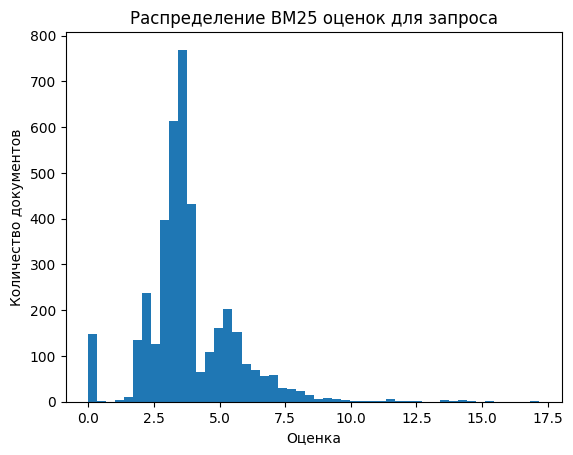

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tokenized_sample = sample_query.lower().split()
scores = bm25.get_scores(tokenized_sample)
plt.hist(scores, bins=50)
plt.title('Распределение BM25 оценок для запроса')
plt.xlabel('Оценка')
plt.ylabel('Количество документов')
plt.show()

### Задание 3. Семантический поиск (BGE-M3) (12 баллов)

Полнотекстовый поиск не понимает синонимов и опечаток. Эту проблему решает семантический поиск с использованием Bi-Encoder архитектуры.
Обе башни энкодера (для документа и для запроса) превращают текст в плотный вектор (эмбеддинг). Релевантность оценивается косинусным расстоянием между векторами.
Мы будем использовать модель `BAAI/bge-m3`, которая отлично работает с русским языком. Для быстрого поиска по векторам применим библиотеку FAISS.

**Что нужно сделать:**
1. Загрузите модель `BAAI/bge-m3` через `SentenceTransformer`.
2. Получите эмбеддинги для всего корпуса `corpus` (это может занять несколько минут на GPU).
3. Создайте FAISS индекс `IndexFlatIP` (внутреннее произведение, что эквивалентно косинусной близости для нормализованных векторов).
4. Добавьте нормализованные векторы корпуса в индекс.
5. Реализуйте функцию `search_semantic(query, k=5)`, которая векторизует запрос, нормализует вектор и ищет топ-K в FAISS.


In [4]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("Загрузка модели BGE-M3...")
# Используем SentenceTransformer для удобства
embedder = SentenceTransformer('BAAI/bge-m3')


# === ВАШ КОД ЗДЕСЬ ===
# 1. Получение эмбеддингов корпуса (используйте batch_size=16 или 32)

print("Начинаем вычисление эмбеддингов для корпуса...")

corpus_embeddings = embedder.encode(
    corpus,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)
print(f"Эмбеддинги получены, форма: {corpus_embeddings.shape}")

# сохранение эмбеддингов в файл, чтобы не пересчитывать заново при перезапуске
np.save('corpus_embeddings.npy', corpus_embeddings)
print("Эмбеддинги сохранены в corpus_embeddings.npy")



# 2. Нормализация векторов (важно для косинусного расстояния в FAISS)

faiss.normalize_L2(corpus_embeddings)

# 3. Создание и заполнение FAISS индекса

dimension = embedder.get_sentence_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
print(f"Индекс FAISS создан, количество векторов в индексе: {index.ntotal}")



# 4. функция семантического поиска
def search_semantic(query, k=5):
    """
    Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов.
    """
    # векторизуем запрос
    query_emb = embedder.encode([query], convert_to_numpy=True)

    # нормализуем вектор запроса
    faiss.normalize_L2(query_emb)

    # выполняем поиск в индексе
    distances, indices = index.search(query_emb, k)

    # возвращаем индексы (первая строка, так как у нас один запрос)
    return indices[0].tolist()



# проверка
print(f"\nЗапрос: {sample_query}")
top_docs = search_semantic(sample_query, k=5)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:200]}...")

print("\n\n")
# === КОНЕЦ ВАШЕГО КОДА ===

Загрузка модели BGE-M3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Начинаем вычисление эмбеддингов для корпуса...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [5]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

# загружаем модель (она уже скачана, повторная загрузка быстрая)
embedder = SentenceTransformer('BAAI/bge-m3')

# загружаем эмбеддинги из сохранённого файла
corpus_embeddings = np.load('corpus_embeddings.npy')
print(f"Эмбеддинги загружены, форма: {corpus_embeddings.shape}")

# нормализуем (если ещё не нормализованы)
faiss.normalize_L2(corpus_embeddings)

# создаём FAISS-индекс
dimension = embedder.get_sentence_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
print(f"Индекс создан, количество векторов: {index.ntotal}")

# восстанавливаем функцию поиска
def search_semantic(query, k=5):
    query_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_emb)
    distances, indices = index.search(query_emb, k)
    return indices[0].tolist()

# проверяем
sample_query = "В каком году был основан Московский университет?"
print(f"\nЗапрос: {sample_query}")
top_docs = search_semantic(sample_query, k=5)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:200]}...")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Эмбеддинги загружены, форма: (3971, 1024)
Индекс создан, количество векторов: 3971

Запрос: В каком году был основан Московский университет?


/tmp/ipykernel_2081/1422191188.py:16: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = embedder.get_sentence_embedding_dimension()


- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факультет нравственных и политических наук, готовящий специалистов в области политики и политической эко...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, которую окончили Л. Ф. Магницкий, В. К. Тредиаковский и М. В. Ломоносов. 28 января (8 февраля) 1724 года ...
- Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Реконкистой в Испании, в итоге чего арабские университеты оказались на землях христианских государств,...
- Старейший вуз города — Рязанский государственный университет был открыт в 1915 году как женский учительский институт и в 1985 году получил имя С. А. Есенина. Рязанский радиотехнический, агротехнологич...
- Московский народный банк, МНБ — банк, учреждённый в 1919 году в Лондоне, Великобритания, советскими организациями для обеспечения внешнеторговой деятельности Советского Союза

Загружены эмбеддинги из corpus_embeddings.npy, форма: (3971, 1024)
Нормализованные эмбеддинги (из переменной) имеют форму: (3971, 1024)

	Информация об эмбеддингах
Количество векторов: 3971
Размерность векторов: 1024
Тип данных: float32

Пример первого вектора (первые kk значений) ДО нормализации:
[ 0.02183051 -0.00015308 -0.01587946  0.05315651 -0.00364301 -0.04220828
  0.01508221 -0.03063751 -0.00701155 -0.00245597]

Пример первого вектора (первые kk значений) ПОСЛЕ нормализации:
[ 0.02183051 -0.00015308 -0.01587946  0.05315651 -0.00364301 -0.04220828
  0.01508221 -0.03063751 -0.00701155 -0.00245597]

	Сравнение норм векторов до и после нормализации (первые kk документов)
Документ | Норма до | Норма после | Отклонение 
       0 | 1.000000 | 1.000000 | 0.0000000000
       1 | 1.000000 | 1.000000 | 0.0000000000
       2 | 1.000000 | 1.000000 | 0.0000001192
       3 | 1.000000 | 1.000000 | 0.0000000596
       4 | 1.000000 | 1.000000 | 0.0000000000
       5 | 1.000000 | 1.000000 | 0.0000

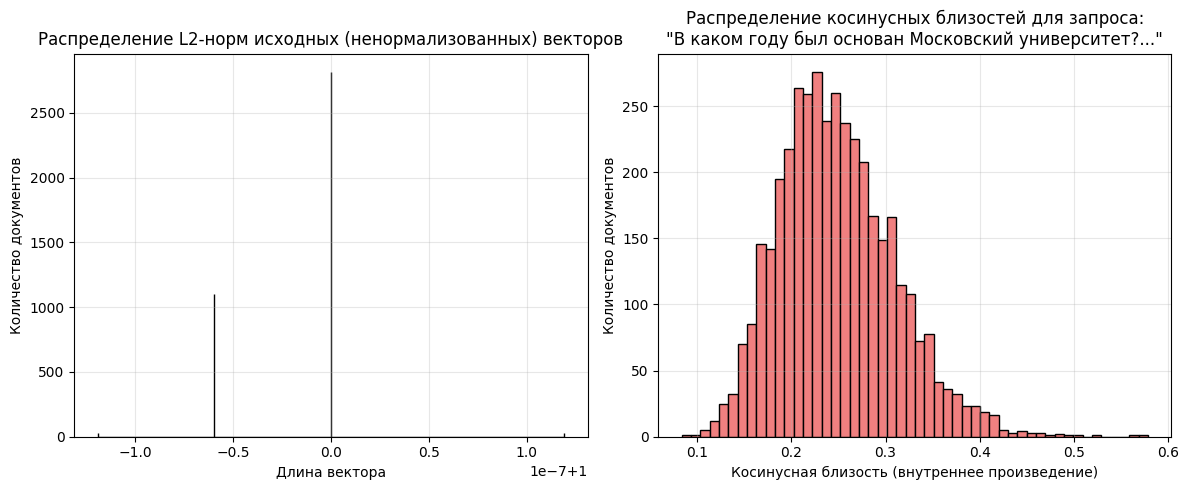


Статистика близостей для запроса:
  Минимум: 0.0838
  Максимум: 0.5784
  Среднее: 0.2484
  Медиана: 0.2427
  Стандартное отклонение: 0.0609

Анализ завершён.


In [ ]:
# Дополнительный анализ
# Дополнительный анализ
# Дополнительный анализ


import matplotlib.pyplot as plt
import numpy as np
import json

# 1. Функция для загрузки эмбеддингов из сохраненного файла

def load_embeddings(filepath='corpus_embeddings.npy'):
    # Загружает эмбеддинги из .npy файла и возвращает массив numpy.

    try:
        embeddings = np.load(filepath)
        print(f"Загружены эмбеддинги из {filepath}, форма: {embeddings.shape}")
        return embeddings
    except FileNotFoundError:
        print(f"Файл {filepath} не найден. Убедитесь, что основной код задания 3 выполнен и эмбеддинги сохранены.")
        return None


# Загружаем ненормализованные эмбеддинги (сохранённые до нормализации)
original_embeddings = load_embeddings('corpus_embeddings.npy')

if original_embeddings is None:
    raise SystemExit("Невозможно продолжить анализ без эмбеддингов.")


# Проверим, что они совпадают по форме с corpus_embeddings
print(f"Нормализованные эмбеддинги (из переменной) имеют форму: {corpus_embeddings.shape}")



# 2. Информация об эмбеддингах
print("\n\tИнформация об эмбеддингах")
print(f"Количество векторов: {original_embeddings.shape[0]}")
print(f"Размерность векторов: {original_embeddings.shape[1]}")
print(f"Тип данных: {original_embeddings.dtype}")


# Выведем первый вектор (первые kk значений) как пример
kk = 10
print("\nПример первого вектора (первые kk значений) ДО нормализации:")
print(original_embeddings[0][:kk])
print("\nПример первого вектора (первые kk значений) ПОСЛЕ нормализации:")
print(corpus_embeddings[0][:kk])



# 3. Сравнение норм векторов до и после нормализации (первые kk документов)
print("\n\tСравнение норм векторов до и после нормализации (первые kk документов)")
print("Документ | Норма до | Норма после | Отклонение ")

for i in range(min(kk, len(original_embeddings))):
    norm_before = np.linalg.norm(original_embeddings[i])
    norm_after = np.linalg.norm(corpus_embeddings[i])
    deviation = abs(norm_after - 1.0)  # после нормализации норма должна быть ровно 1
    print(f"{i:8d} | {norm_before:.6f} | {norm_after:.6f} | {deviation:.10f}")

# Проверим, что все нормализованные векторы имеют норму 1
all_norms = np.linalg.norm(corpus_embeddings, axis=1)
max_deviation = np.max(np.abs(all_norms - 1.0))

print(f"\nМаксимальное отклонение нормы от 1 среди всех векторов: {max_deviation:.10f}")


# 4. Визуализации
# 4.1 Гистограмма распределения длин (норм) исходных векторов

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
norms_original = np.linalg.norm(original_embeddings, axis=1)
plt.hist(norms_original, bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение L2-норм исходных (ненормализованных) векторов')
plt.xlabel('Длина вектора')
plt.ylabel('Количество документов')
plt.grid(True, alpha=0.3)

# 4.2 Гистограмма косинусных близостей для sample_query (если sample_query определён)
# Заново выполним поиск, чтобы получить расстояния
if 'sample_query' in globals():
    query_emb = embedder.encode([sample_query], convert_to_numpy=True)
    faiss.normalize_L2(query_emb)
    distances, _ = index.search(query_emb, len(corpus))  # ищем все расстояния, не только топ-K
    # distances имеет форму (1, N), извлекаем первый ряд
    distances = distances[0]

    plt.subplot(1, 2, 2)
    plt.hist(distances, bins=50, color='lightcoral', edgecolor='black')
    plt.title(f'Распределение косинусных близостей для запроса:\n"{sample_query[:50]}..."')
    plt.xlabel('Косинусная близость (внутреннее произведение)')
    plt.ylabel('Количество документов')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Переменная sample_query не найдена, пропускаем гистограмму близостей.")



# Cтатистика по близостям
if 'distances' in locals():
    print(f"\nСтатистика близостей для запроса:")
    print(f"  Минимум: {np.min(distances):.4f}")
    print(f"  Максимум: {np.max(distances):.4f}")
    print(f"  Среднее: {np.mean(distances):.4f}")
    print(f"  Медиана: {np.median(distances):.4f}")
    print(f"  Стандартное отклонение: {np.std(distances):.4f}")

print("\nАнализ завершён.")



### Задание 4. Оценка качества: BM25 vs Семантика (8 баллов)

Теперь давайте количественно сравним два подхода на нашей отложенной тестовой выборке из 200 вопросов.
Ниже предоставлена функция оценки. Она считает, что документ релевантен, если подстрока `ground_truth` (правильный ответ) содержится в тексте найденного документа.

**Что нужно сделать:**
1. Изучите код функции `evaluate_retriever`.
2. Запустите оценку для `search_bm25` и `search_semantic` с `k=5`.
3. Постройте столбчатую диаграмму (bar chart) для наглядного сравнения метрик Recall@5 и MRR@5 двух алгоритмов.


In [6]:
import time

def evaluate_retriever(search_func, queries_data, corpus, k=5):
    recall_hits = 0
    mrr_sum = 0
    start_time = time.time()

    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()

        # Получаем топ-K doc_ids
        retrieved_ids = search_func(query, k=k)

        hit_rank = None
        for rank, doc_id in enumerate(retrieved_ids):
            doc_text = corpus[doc_id].lower()
            if ground_truth in doc_text:
                hit_rank = rank + 1
                break

        if hit_rank is not None:
            recall_hits += 1
            mrr_sum += 1.0 / hit_rank

    latency = time.time() - start_time

    recall = recall_hits / len(queries_data)
    mrr = mrr_sum / len(queries_data)
    avg_latency_ms = (latency / len(queries_data)) * 1000

    return {"Recall@K": recall, "MRR@K": mrr, "Latency_ms": avg_latency_ms}


           Метод  Recall@5     MRR@5  Latency (ms)
0           BM25     0.835  0.781083     19.970405
1  Семантический     0.925  0.883333    599.586148


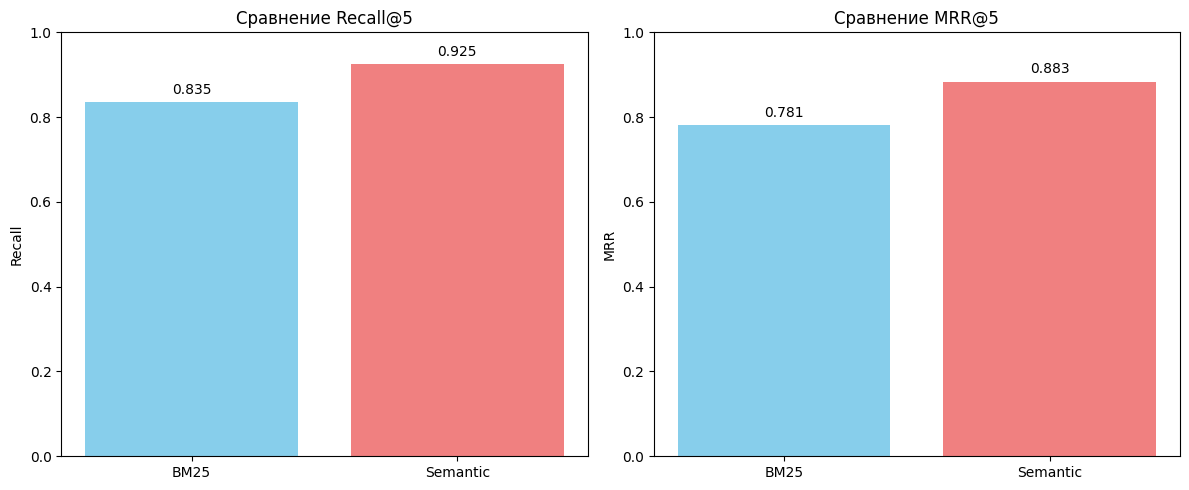

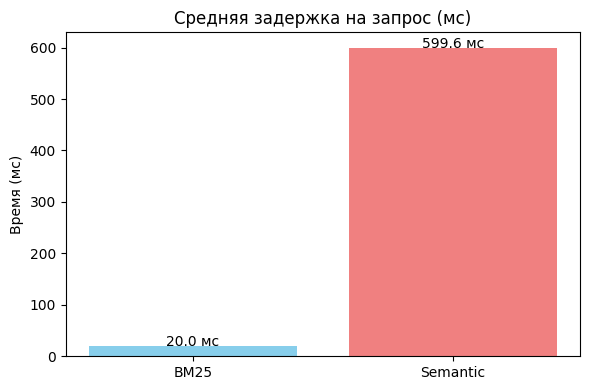

In [7]:

# === ВАШ КОД ЗДЕСЬ ===
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np



# 1. Запуск оценки
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)

# 2. Визуализация результатов (matplotlib или seaborn)
# Таблица
metrics_df = pd.DataFrame({
    'Метод': ['BM25', 'Семантический'],
    'Recall@5': [bm25_metrics['Recall@K'], semantic_metrics['Recall@K']],
    'MRR@5': [bm25_metrics['MRR@K'], semantic_metrics['MRR@K']],
    'Latency (ms)': [bm25_metrics['Latency_ms'], semantic_metrics['Latency_ms']]
})
print(metrics_df)




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

methods = ['BM25', 'Semantic']
recall_values = [bm25_metrics['Recall@K'], semantic_metrics['Recall@K']]
mrr_values = [bm25_metrics['MRR@K'], semantic_metrics['MRR@K']]

# Сравнение Recall@5
ax1.bar(methods, recall_values, color=['skyblue', 'lightcoral'])
ax1.set_title('Сравнение Recall@5')
ax1.set_ylabel('Recall')
ax1.set_ylim(0, 1)
for i, v in enumerate(recall_values):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center')

# Сравнение MRR@5
ax2.bar(methods, mrr_values, color=['skyblue', 'lightcoral'])
ax2.set_title('Сравнение MRR@5')
ax2.set_ylabel('MRR')
ax2.set_ylim(0, 1)
for i, v in enumerate(mrr_values):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# Средняя задержка на запрос (мс)
fig, ax = plt.subplots(figsize=(6, 4))
latency_values = [bm25_metrics['Latency_ms'], semantic_metrics['Latency_ms']]
ax.bar(methods, latency_values, color=['skyblue', 'lightcoral'])
ax.set_title('Средняя задержка на запрос (мс)')
ax.set_ylabel('Время (мс)')
for i, v in enumerate(latency_values):
    ax.text(i, v + 0.5, f'{v:.1f} мс', ha='center')
plt.tight_layout()
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===

In [ ]:
# (Не обязательно)
# ДОполнительный код, для себя, для скачивания файлов с данными из датасетов

import json
import numpy as np
import faiss
import pickle
import os

SAVE_DIR = "saved_data"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_all_data(corpus, corpus_dict, test_queries, corpus_embeddings, index):
    """
    Сохраняет все ключевые объекты в папку SAVE_DIR.
    - corpus: список текстов (JSON)
    - corpus_dict: словарь id->text (JSON)
    - test_queries: список словарей (JSON)
    - corpus_embeddings: массив numpy (ненормализованный)
    - index: FAISS индекс (бинарный файл)
    """
    # сохранение corpus
    with open(os.path.join(SAVE_DIR, 'corpus.json'), 'w', encoding='utf-8') as f:
        json.dump(corpus, f, ensure_ascii=False, indent=2)

    # сохранение corpus_dict (уже есть, но пересохраним для единообразия)
    with open(os.path.join(SAVE_DIR, 'corpus_dict.json'), 'w', encoding='utf-8') as f:
        json.dump(corpus_dict, f, ensure_ascii=False, indent=2)

    # сохранение test_queries
    with open(os.path.join(SAVE_DIR, 'test_queries.json'), 'w', encoding='utf-8') as f:
        json.dump(test_queries, f, ensure_ascii=False, indent=2)

    # сохранение эмбеддингов (ненормализованных)
    np.save(os.path.join(SAVE_DIR, 'corpus_embeddings.npy'), corpus_embeddings)

    # сохранение FAISS индекса
    faiss.write_index(index, os.path.join(SAVE_DIR, 'faiss_index.bin'))

    print(f"Все данные сохранены в папку '{SAVE_DIR}'")

def load_all_data(embedder):
    """
    Загружает все сохранённые данные и восстанавливает FAISS-индекс.
    Возвращает кортеж (corpus, corpus_dict, test_queries, index).
    Примечание: модель embedder должна быть уже загружена (SentenceTransformer),
    чтобы можно было получить размерность при создании индекса.
    """
    # загрузка корпуса
    with open(os.path.join(SAVE_DIR, 'corpus.json'), 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    # загрузка corpus_dict
    with open(os.path.join(SAVE_DIR, 'corpus_dict.json'), 'r', encoding='utf-8') as f:
        corpus_dict = json.load(f)
        # преобразуем ключи из строк в int (если нужно)
        corpus_dict = {int(k): v for k, v in corpus_dict.items()}

    # загрузка test_queries
    with open(os.path.join(SAVE_DIR, 'test_queries.json'), 'r', encoding='utf-8') as f:
        test_queries = json.load(f)

    # загрузка эмбеддингов (ненормализованных)
    corpus_embeddings = np.load(os.path.join(SAVE_DIR, 'corpus_embeddings.npy'))

    # загрузка FAISS индекса
    index = faiss.read_index(os.path.join(SAVE_DIR, 'faiss_index.bin'))

    print("Все данные загружены.")
    print(f"Корпус: {len(corpus)} документов, тестов: {len(test_queries)}")
    return corpus, corpus_dict, test_queries, index

In [ ]:
save_all_data(corpus, corpus_dict, test_queries, corpus_embeddings, index)

Все данные сохранены в папку 'saved_data'


### Задание 5. RAG с декодером (Qwen3.5-9B) (7 баллов)

Поиск — это только половина RAG. Вторая половина — генерация ответа с помощью декодерной LLM.
Мы будем использовать модель `Qwen/Qwen3.5-9B-Instruct`. Вы можете вызывать ее через API (например, бесплатный OpenRouter) или загрузить локально, если позволяет видеопамять.

**Что нужно сделать:**
1. Реализуйте функцию `generate_answer(query, context_docs)`, которая формирует промпт (инструкция + контексты + вопрос) и вызывает LLM для получения ответа.
2. Напишите обертку `rag_pipeline(query, search_func, k=3)`, которая сначала ищет документы, а затем генерирует ответ.
3. Протестируйте ваш пайплайн на 3-5 любых вопросах (можно придумать свои), используя семантический поиск. Выведите вопрос, найденный контекст и ответ LLM.


### Локальная модель слишком долго скачивалась, поэтому я использовал API
### когда я первый раз пытался ее скачать у меня ушло 10 минут на 30 процентов скачивания модели

чуть ниже будет код с локальной моделью

In [ ]:
# Локальная модель слишком долго скачивалась, поэтому я использовал API
# когда я первый раз пытался ее скачать у меня ушло 10 минут на 30 процентов скачивания модели

import os

# Если используете OpenRouter API:
# from openai import OpenAI
# client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key="YOUR_API_KEY")


# === ВАШ КОД ЗДЕСЬ ===
# установка библиотек
# установка библиотек

print("0.")
!pip install -q transformers>=4.50 accelerate bitsandbytes torch

from google.colab import userdata
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# получаем токен из секретов Colab (создайте секрет HF_TOKEN)
print("1.")
hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Создайте секрет HF_TOKEN в Colab с вашим токеном Hugging Face.")

# используем актуальную модель
print("2.")
model_name = "Qwen/Qwen3.5-9B"

# 8-битная квантизация
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_use_double_quant=True,
)

print("Загрузка модели и токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    token=hf_token,           # явно передаём токен
    trust_remote_code=True,
)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    token=hf_token,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
print("Модель загружена.")






0.
1.
2.
Загрузка модели и токенизатора...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

### К моему сожалению, я использовал :  model="openrouter/free"
### т.к. локальная модель долго скачивалать, а на openrouter нужная модель была платной.

In [8]:
# К моему сожалению, я использовал :
#  model="openrouter/free"
# т.к. локальная модель долго скачивалать, а на openrouter нужная модель была платной.

import os
# Если используете OpenRouter API:
# from openai import OpenAI
# client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key="YOUR_API_KEY")


# === ВАШ КОД ЗДЕСЬ ===
import os
from openai import OpenAI
from google.colab import userdata


# инициализация клиента OpenRouter
# замените "YOUR_API_KEY" на ваш реальный ключ, либо используйте переменную окружения
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key= userdata.get('API_KEY'),  # секрет гугл колаба
)

def generate_answer(query, context_docs):
    # Формирует промпт и вызывает LLM.
    # Возвращает текстовый ответ.

    # prompt = f"Используй только следующий контекст для ответа на вопрос.\nКонтекст:\n{context_docs}\n\nВопрос: {query}\nОтвет:"

    prompt = f"""
    Ты — помощник редактора. Отвечай на вопросы, используя ТОЛЬКО информацию из приведённого ниже контекста.
    Отвечай в одно, три предложения, не более.
    Если ответа нет в контексте, скажи "Информация не найдена".

Контекст:
{context_docs}

Вопрос: {query}

Ответ:"""

    try:
        response = client.chat.completions.create(
            model="openrouter/free",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=250,
            temperature=0.2,
        )

        # проверяем, есть ли содержимое
        content = response.choices[0].message.content
        if content is None:
            return "Модель не вернула ответ (содержимое пустое). Попробуйте другой запрос."

        return content.strip()
    except Exception as e:
        return f"Ошибка при вызове LLM: {e}"





def rag_pipeline(query, search_func, k=3):
    # 1. поиск документов
    doc_ids = search_func(query, k=k)

    # 2. Объединение текстов документов в одну строку
    context_parts = [corpus[doc_id] for doc_id in doc_ids]
    context_docs = "\n---\n".join(context_parts)

    # 3. генерация ответа
    answer = generate_answer(query, context_docs)
    return answer







# Тестирование на 3 вопросах из тестовой выборки (первые 3 для примера)
print("Тестирование RAG пайплайна:\n")
for i in range(3):
    question = test_queries[i]['question']
    print(f"Вопрос {i+1}: {question}")

    # выводим контекст (первые 200 символов каждого документа)
    doc_ids = search_semantic(question, k=3)
    print("Контекст (кратко):")
    for idx, doc_id in enumerate(doc_ids):
        preview = corpus[doc_id][:200].replace('\n', ' ')
        print(f"  Документ {idx+1}: {preview}...")

    # получаем и выводим ответ
    answer = rag_pipeline(question, search_semantic, k=3)
    print(f"Ответ LLM: {answer}\n")
    print("-" * 80)
# === КОНЕЦ ВАШЕГО КОДА ===

Тестирование RAG пайплайна:

Вопрос 1: Что постепенно ослабевает под влиянием славянских языков в румынском языке?
Контекст (кратко):
  Документ 1: Румы́нский язы́к (самоназвание — Limba română, МФА: limba ro’mɨnə; ранее также валашский, влашский, волошский, валахо-молдавский язык) — индоевропейский язык, входящий в балкано-романскую подгруппу ро...
  Документ 2: В фонетике влияние славян приводит к развитию не только к позиционной палатализации согласных (лат. oculus → ochi /окь/ — глаз ), но и смыслоразличительной палатализации путём переозвучивания латински...
  Документ 3: Трансформация народно-латинского языка в румынский носила длительный и постепенный характер. Первичная романизация привела к появлению восточно-романского диалекта, получившего наименование балканская...
Ответ LLM: Модель не вернула ответ (содержимое пустое). Попробуйте другой запрос.

--------------------------------------------------------------------------------
Вопрос 2: Кого, стремящегося к получению большег

# **! Дисклеймер!**

Изначально я использовал бесплатную модель, но у меня кончелись бесплатные вызовы к модели.

И я случайно перезагрузил этот код.

### ! Но в Задаче 9 я вызываю как раз этот способ (только уже через локальную модель). Работу этого кода можно посмотреть ниже в 9 задаче.

In [ ]:
# выведите все бесплатные модели
models = client.models.list()
for m in models.data:
    if ':free' in m.id:
        print(m.id)

tencent/hy3:free
poolside/laguna-xs-2.1:free
cohere/north-mini-code:free
nvidia/nemotron-3.5-content-safety:free
nvidia/nemotron-3-ultra-550b-a55b:free
nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
poolside/laguna-m.1:free
google/gemma-4-26b-a4b-it:free
google/gemma-4-31b-it:free
nvidia/nemotron-3-super-120b-a12b:free
nvidia/nemotron-3-nano-30b-a3b:free
nvidia/nemotron-nano-12b-v2-vl:free
nvidia/nemotron-nano-9b-v2:free
openai/gpt-oss-20b:free


### Задание 6. Оценка стоимости запросов (5 баллов)

В коммерческой разработке важно понимать экономику продукта. Провайдеры API тарифицируют токены (входные и выходные).
Размер входного промпта напрямую зависит от количества передаваемых чанков (найденных документов) и их длины. Длина ответа контролируется системным промптом.

**Что нужно сделать:**
1. Используя библиотеку `tiktoken` (энкодер `cl100k_base` близок к большинству современных LLM), напишите функцию `estimate_cost(query, retrieved_docs, max_output_tokens)`.
2. Предположим тариф: $0.50 за 1M входных токенов и $1.50 за 1M выходных токенов.
3. Посчитайте среднюю стоимость 1000 запросов для трех сценариев:
   - k=1 (передаем 1 документ), короткий ответ (max 50 токенов)
   - k=3 (передаем 3 документа), средний ответ (max 150 токенов)
   - k=5 (передаем 5 документов), развернутый ответ (max 300 токенов)
4. В качестве запроса и документов используйте усредненные длины из вашего тестового набора.


Расчёт стоимости для трёх сценариев:
              Сценарий  k  max_output_tokens  Средняя стоимость 1 запроса ($)  Стоимость 1000 запросов ($)
   k=1, короткий ответ  1                 50                         0.000341                      0.34105
    k=3, средний ответ  3                150                         0.000839                      0.83850
k=5, развернутый ответ  5                300                         0.001418                      1.41835


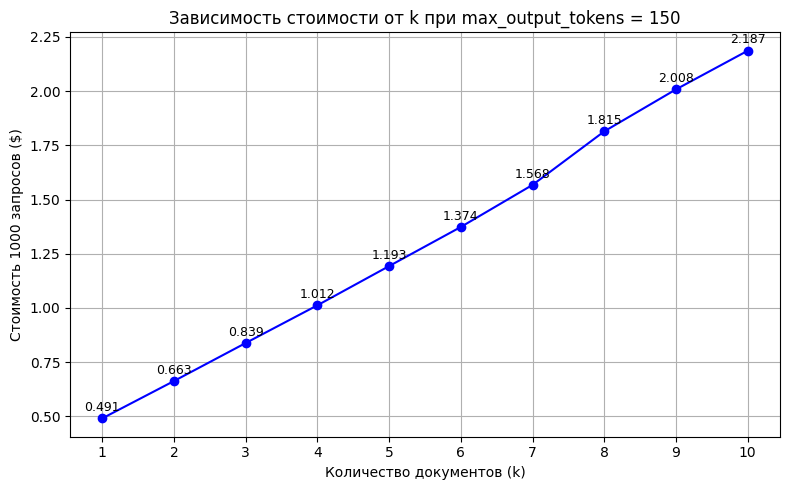

In [9]:
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt

encoding = tiktoken.get_encoding("cl100k_base")



def estimate_cost(query_text, docs_texts, max_output_tokens):
    """
    Возвращает стоимость одного запроса в долларах.
    """
    context_docs = "\n---\n".join(docs_texts)
    prompt = f"""
Ты — помощник редактора. Отвечай на вопросы, используя ТОЛЬКО информацию из приведённого ниже контекста.
Отвечай в одно-три предложения, не более.
Если ответа нет в контексте, скажи "Информация не найдена".

Контекст:
{context_docs}

Вопрос: {query_text}

Ответ:"""
    input_tokens = len(encoding.encode(prompt))
    output_tokens = max_output_tokens
    cost = (input_tokens / 1e6) * 0.50 + (output_tokens / 1e6) * 1.50
    return cost




# для расчёта усреднённой стоимости для трех возьмём первые 20 запросов и усредним
sample_size = 20
sample_queries = test_queries[:sample_size]

scenarios = [
    {"k": 1, "max_tokens": 50, "label": "k=1, короткий ответ"},
    {"k": 3, "max_tokens": 150, "label": "k=3, средний ответ"},
    {"k": 5, "max_tokens": 300, "label": "k=5, развернутый ответ"},
]

results = []
for scenario in scenarios:
    k = scenario["k"]
    max_tokens = scenario["max_tokens"]
    total_cost = 0.0

    for item in sample_queries:
        query = item['question']
        # получаем k документов (используем семантический поиск)
        doc_ids = search_semantic(query, k=k)
        docs_texts = [corpus[doc_id] for doc_id in doc_ids]
        cost = estimate_cost(query, docs_texts, max_tokens)
        total_cost += cost

    avg_cost_per_query = total_cost / sample_size
    cost_per_1000 = avg_cost_per_query * 1000

    results.append({
        "Сценарий": scenario["label"],
        "k": k,
        "max_output_tokens": max_tokens,
        "Средняя стоимость 1 запроса ($)": avg_cost_per_query,
        "Стоимость 1000 запросов ($)": cost_per_1000,
    })

df = pd.DataFrame(results)
print("Расчёт стоимости для трёх сценариев:")
print(df.to_string(index=False))



# график зависимости стоимости от k (при фиксированных выходных токенах = 150)
ks = list(range(1, 11))
fixed_max_tokens = 150
costs_per_1000 = []

for k in ks:
    total_cost = 0.0
    for item in sample_queries:
        query = item['question']
        doc_ids = search_semantic(query, k=k)
        docs_texts = [corpus[doc_id] for doc_id in doc_ids]
        cost = estimate_cost(query, docs_texts, fixed_max_tokens)
        total_cost += cost

    avg_cost_per_query = total_cost / sample_size
    costs_per_1000.append(avg_cost_per_query * 1000)


plt.figure(figsize=(8, 5))
plt.plot(ks, costs_per_1000, marker='o', linestyle='-', color='b')
plt.xlabel('Количество документов (k)')
plt.ylabel('Стоимость 1000 запросов ($)')
plt.title(f'Зависимость стоимости от k при max_output_tokens = {fixed_max_tokens}')
plt.grid(True)
plt.xticks(ks)

for x, y in zip(ks, costs_per_1000):
    plt.text(x, y + 0.02, f'{y:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===

---
# Часть 2. Продвинутое ДЗ (50 баллов)

В этой части мы улучшим качество поиска, объединив сильные стороны BM25 и семантики, а также добавим этап переранжирования (Reranking).


### Задание 7. Гибридный поиск (RRF) (10 баллов)

BM25 хорош для точных совпадений (имена, артикулы), а семантика — для понимания смысла. Гибридный поиск объединяет их выдачу.
Один из лучших способов объединения списков разной природы без настройки весов — Reciprocal Rank Fusion (RRF).
Формула RRF: $Score(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$, где $rank_r(d)$ — позиция документа в выдаче конкретного ретривера, а $k$ — константа сглаживания (обычно 60).

**Что нужно сделать:**
1. Реализуйте функцию `search_hybrid(query, k=5, rrf_k=60)`.
2. Внутри функции сделайте запрос к `search_bm25` (получите топ-20) и к `search_semantic` (получите топ-20).
3. Примените формулу RRF для подсчета итоговых скоров документов.
4. Отсортируйте документы по убыванию RRF-скора и верните топ-K.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
def search_hybrid(query, k=5, rrf_k=60):
    """
    Выполняет гибридный поиск с использованием RRF.
    """
    # получаем топ-20 от каждого ретривера
    bm25_ids = search_bm25(query, k=20)
    semantic_ids = search_semantic(query, k=20)

    rrf_scores = {}
    # обрабатываем BM25
    for rank, doc_id in enumerate(bm25_ids, start=1):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)
    # обрабатываем семантику
    for rank, doc_id in enumerate(semantic_ids, start=1):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)

    # сортируем по убыванию скора
    sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in sorted_docs[:k]]



# Проверка

sample_query = "В каком году был основан Московский университет?"
# print(search_hybrid(sample_query, k=3))
print("Вопрос: В каком году был основан Московский университет?\n")
print("Гибридный поиск (топ-3):", search_hybrid(sample_query, k=3))
for doc_id in search_hybrid(sample_query, k=3):
    print(f"- {corpus[doc_id][:150]}...")
print("\n\n")

print("Вопрос: В каком году был основан Московский университет?\n")
print("Гибридный поиск (топ-10):", search_hybrid(sample_query, k=10))
for doc_id in search_hybrid(sample_query, k=10):
    print(f"- {corpus[doc_id][:150]}...")
print("\n\n")


sample_query = "Важнейшие университеты в истории России."
print("Вопрос: Важнейшие университеты в истории России.\n")
print("Гибридный поиск (топ-10):", search_hybrid(sample_query, k=10))
for doc_id in search_hybrid(sample_query, k=10):
    print(f"- {corpus[doc_id][:150]}...")

# === КОНЕЦ ВАШЕГО КОДА ===


Вопрос: В каком году был основан Московский университет?

Гибридный поиск (топ-3): [2403, 16, 1206]
- Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитрихе фон Райтенау, Маркусе фон Хоэмесе и Парисе Лод...
- Московский народный банк, МНБ — банк, учреждённый в 1919 году в Лондоне, Великобритания, советскими организациями для обеспечения внешнеторговой деяте...
- В середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кредит доступным для других секторов экономики. В 193...



Вопрос: В каком году был основан Московский университет?

Гибридный поиск (топ-10): [2403, 16, 1206, 2340, 1594, 2119, 1413, 2920, 1936, 3548]
- Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитрихе фон Райтенау, Маркусе фон Хоэмесе и Парисе Лод...
- Московский народный банк, МНБ — банк, учреждённый в 1919 году в Лондоне, Великобритания, советскими организациями для обеспечени

### Задание 8. Переранжирование (Cross-Encoder) (12 баллов)

Bi-Encoder (наш BGE-M3) быстр, так как векторы документов предвычисляются. Но он упускает тонкие взаимосвязи между запросом и документом.
Cross-Encoder принимает на вход пару (Запрос, Документ) одновременно и прогоняет их через все слои внимания трансформера. Это медленно, поэтому его применяют только к небольшому топу кандидатов (переранжирование).

Мы будем использовать `BAAI/bge-reranker-v2-m3`.

**Что нужно сделать:**
1. Загрузите модель cross-encoder (через `SentenceTransformer` или `CrossEncoder`).
2. Реализуйте функцию `search_with_reranking(query, k=5, top_n_initial=20)`.
3. Внутри: получите `top_n_initial` кандидатов через `search_hybrid`.
4. Сформируйте пары `(query, doc_text)` для всех кандидатов и передайте их в cross-encoder для получения скоров.
5. Отсортируйте кандидатов по скорам cross-encoder и верните итоговые топ-K.


In [ ]:
from sentence_transformers import CrossEncoder

print("Загрузка модели Reranker...")
reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')


# === ВАШ КОД ЗДЕСЬ ===
def search_with_reranking(query, k=5, top_n_initial=20):
    """
    Двухстадийный поиск: гибридный (топ-20) -> reranker (топ-K).
    """
    # получаем кандидатов (топ-N от гибридного поиска)
    candidate_ids = search_hybrid(query, k=top_n_initial)

    # формируем пары (запрос и текст документа)
    pairs = [(query, corpus[doc_id]) for doc_id in candidate_ids]

    # сохранение скор от cross-encoder
    scores = reranker.predict(pairs)

    # 4. объединение ID и скоры, м сортировка по убыванию
    scored_docs = list(zip(candidate_ids, scores))
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    # топ-K ID
    return [doc_id for doc_id, _ in scored_docs[:k]]


# Проверка

sample_query = "В каком году был основан Московский университет?"
print("Запрос:", sample_query)
print("\nРезультаты с переранжированием (топ-3):")
for doc_id in search_with_reranking(sample_query, k=3):
    print(f"- {corpus[doc_id][:200]}...")
# === КОНЕЦ ВАШЕГО КОДА ===

Загрузка модели Reranker...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Запрос: В каком году был основан Московский университет?

Результаты с переранжированием (топ-3):
- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факультет нравственных и политических наук, готовящий специалистов в области политики и политической эко...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, которую окончили Л. Ф. Магницкий, В. К. Тредиаковский и М. В. Ломоносов. 28 января (8 февраля) 1724 года ...
- В России до революции 1917 г. понятие кафедры связывалось не столько с административным подразделением, сколько с должностью профессора[3]. В соответствии с практикой европейских университетов в униве...


In [ ]:
sample_query = "Кто основал Московский университет?"
print("Запрос:", sample_query)
print("\nРезультаты с переранжированием (топ-10):")
for doc_id in search_with_reranking(sample_query, k=10):
    print(f"- {corpus[doc_id][:200]}...")

Запрос: Кто основал Московский университет?

Результаты с переранжированием (топ-10):
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, которую окончили Л. Ф. Магницкий, В. К. Тредиаковский и М. В. Ломоносов. 28 января (8 февраля) 1724 года ...
- Дми́трий Ива́нович Менделе́ев (27 января [8 февраля] 1834 года, Тобольск — 20 января [2 февраля] 1907 года, Санкт-Петербург) — русский учёный-энциклопедист: химик, физикохимик, физик, метролог, эконом...
- Мари́я Склодо́вская-Кюри́ (фр. Marie Curie, польск. Maria Skłodowska-Curie; урождённая Мария Саломея Склодовская, польск. Maria Salomea Skłodowska; 7 ноября 1867 года, Варшава, Царство Польское, Росси...
- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факультет нравственных и политических наук, готовящий специалистов в области политики и политической эко...
- В 1843 году П. И. Юшкова, взяв на себя роль опекунши своих несовершеннолетних племяннико

### Задание 9. Полный пайплайн с переранжированием и LLM (8 баллов)

Теперь у нас есть мощный поисковый движок. Давайте обновим наш генеративный пайплайн.

**Что нужно сделать:**
1. Создайте функцию `advanced_rag_pipeline(query)`, которая использует `search_with_reranking` (k=3) для поиска контекста и ту же LLM (Qwen3.5-9B) для генерации.
2. Протестируйте на тех же 3-5 вопросах, что и в Задании 5.
3. В комментариях кратко отметьте, изменилось ли качество или детализация ответов.


### **Примечание**

Ниже находится код, который использовал вызов модели через api. Но из-за исчерпания лимита, я не смог доделать этот вариант исполнения.

**Ниже будет код с реализацией через локальную модель.**

In [ ]:
# Тут я переписал (создал клон) функцию отвечающую за отпраку запроса к конкретной модели,
# т.к.  openrouter/free перестал отвечать
#


def generate_answer_one_model(query, context_docs):
    # Формирует промпт и вызывает LLM.
    # Возвращает текстовый ответ.

    # prompt = f"Используй только следующий контекст для ответа на вопрос.\nКонтекст:\n{context_docs}\n\nВопрос: {query}\nОтвет:"

    prompt = f"""
    Ты — помощник редактора. Отвечай на вопросы, используя ТОЛЬКО информацию из приведённого ниже контекста.
    Отвечай в одно, три предложения, не более.
    Если ответа нет в контексте, скажи "Информация не найдена".

Контекст:
{context_docs}

Вопрос: {query}

Ответ:"""

    try:
        response = client.chat.completions.create(
            model="nvidia/nemotron-nano-9b-v2:free",
            # openrouter/free
            #
            messages=[{"role": "user", "content": prompt}],
            max_tokens=250,
            temperature=0.2,
        )

        # проверяем, есть ли содержимое
        content = response.choices[0].message.content
        if content is None:
            return "Модель не вернула ответ (содержимое пустое). Попробуйте другой запрос."

        return content.strip()
    except Exception as e:
        return f"Ошибка при вызове LLM: {e}"


def rag_pipeline_one_model(query, search_func, k=3):
    # 1. поиск документов
    doc_ids = search_func(query, k=k)

    # 2. Объединение текстов документов в одну строку
    context_parts = [corpus[doc_id] for doc_id in doc_ids]
    context_docs = "\n---\n".join(context_parts)

    # 3. генерация ответа
    answer = generate_answer_one_model(query, context_docs)
    return answer

In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
def advanced_rag_pipeline_one_model(query, k=3):
    """
    Продвинутый RAG пайплайн с переранжированием.
    """
    doc_ids = search_with_reranking(query, k=k)
    context_parts = [corpus[doc_id] for doc_id in doc_ids]
    context_docs = "\n---\n".join(context_parts)
    return generate_answer_one_model(query, context_docs)

# тестирование
# (на тех же вопросах, что и в задании 5)

print("Сравнение базового и продвинутого RAG:\n")
for i in range(3):
    question = test_queries[i]['question']
    print(f"Вопрос {i+1}: {question}")

    # базовый RAG (семантический поиск)
    base_answer = rag_pipeline_one_model(question, search_semantic, k=3)   # предполагается, что rag_pipeline определена
    time.sleep(2)
    # продвинутый RAG (с переранжированием)
    advanced_answer = advanced_rag_pipeline_one_model(question, k=3)
    time.sleep(2)

    print(f"Базовый ответ: {base_answer}")
    print(f"Продвинутый ответ: {advanced_answer}")
    print("-" * 80)

# визуализация сравнения в виде таблицы
import pandas as pd
comparison_df = pd.DataFrame({
    "Вопрос": [test_queries[i]['question'] for i in range(3)],
    "Базовый RAG": [rag_pipeline(test_queries[i]['question'], search_semantic, k=3) for i in range(3)],
    "Продвинутый RAG": [advanced_rag_pipeline(test_queries[i]['question'], k=3) for i in range(3)]
})
print("\nТаблица сравнения:")
print(comparison_df.to_string(index=False))


# === КОНЕЦ ВАШЕГО КОДА ===


Сравнение базового и продвинутого RAG:

Вопрос 1: Что постепенно ослабевает под влиянием славянских языков в румынском языке?
Базовый ответ: Ошибка при вызове LLM: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '50', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1784592000000'}, 'provider_name': None}}, 'user_id': 'user_3GVUMft2UR6ZawXxdt2HSdpfiqr'}
Продвинутый ответ: Ошибка при вызове LLM: Error code: 429 - {'error': {'message': 'Rate limit exceeded: free-models-per-day. Add 10 credits to unlock 1000 free model requests per day', 'code': 429, 'metadata': {'headers': {'X-RateLimit-Limit': '50', 'X-RateLimit-Remaining': '0', 'X-RateLimit-Reset': '1784592000000'}, 'provider_name': None}}, 'user_id': 'user_3GVUMft2UR6ZawXxdt2HSdpfiqr'}
--------------------------------------------------------------------------------
Вопрос 2: Кого,

### **Примечание**

Ниже будет код с реализацией через локальную модель.

### **"Qwen/Qwen2.5-3B-Instruct"**

***В начале я использовал 0.5B-модель***. Но она довала не корректные ответы. Она спокойно, зацикливалась, писала абракодабру, переписыпала промт в ответ.

In [ ]:
# Блок 1: Загрузка локальной модели и интерфейс для взаимодействия


!pip install -q transformers accelerate torch bitsandbytes

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# конфигурация квантизации (4-бит)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# загрузка модели и токенизатора
model_id = "Qwen/Qwen2.5-3B-Instruct"
print("Загрузка токенизатора...")
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
# устанавливаем pad_token, если его нет
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Загрузка модели (4-бит)...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True,
)
print(f"Модель загружена на устройство: {model.device}\n")

def generate_local(prompt, max_new_tokens=250, temperature=0.2):
    """
    Генерирует ответ на промпт с помощью локальной модели.
    Возвращает строку с ответом (без промпта).
    """
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    # декодируем только новые токены (ответ)
    input_length = inputs.input_ids.shape[1]
    generated_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    return answer.strip()

print("Локальная модель готова к работе.")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 8.9 MB/s eta 0:00:00
Загрузка токенизатора...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/default/ops.py:223: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [ ]:
# Блок 2: непосредственное выполнение задания
# RAG пайплай с локальной моделью (Задание 9)
import time

# переопределяем генератор ответов – теперь локальный
def generate_answer_local(query, context_docs):
    prompt = f"""
Ты — помощник редактора. Отвечай на вопросы, используя ТОЛЬКО информацию из приведённого ниже контекста.
Отвечай в одно-три предложения, не более.
Если ответа нет в контексте, скажи "Информация не найдена".

Контекст:
{context_docs}

Вопрос: {query}

Ответ:"""
    return generate_local(prompt, max_new_tokens=250, temperature=0.2)

# адаптируем пайплайны
def rag_pipeline_local(query, search_func, k=3):
    doc_ids = search_func(query, k=k)
    context_parts = [corpus[doc_id] for doc_id in doc_ids]
    context_docs = "\n---\n".join(context_parts)
    return generate_answer_local(query, context_docs)

def advanced_rag_pipeline_local(query, k=3):
    doc_ids = search_with_reranking(query, k=k)
    context_parts = [corpus[doc_id] for doc_id in doc_ids]
    context_docs = "\n---\n".join(context_parts)
    return generate_answer_local(query, context_docs)

# тестирование на тех же вопросах
print("Сравнение базового и продвинутого RAG (локальная модель):\n")
for i in range(3):
    question = test_queries[i]['question']
    print(f"Вопрос {i+1}: {question}")

    base_answer = rag_pipeline_local(question, search_semantic, k=3)
    # time.sleep(1)  # небольшая пауза между запросами (не обязательна)
    advanced_answer = advanced_rag_pipeline_local(question, k=3)
    # time.sleep(1)

    print(f"Базовый ответ: {base_answer}")
    print(f"Продвинутый ответ: {advanced_answer}")
    print("-" * 80)

# визуализация сравнения
import pandas as pd
comparison_df = pd.DataFrame({
    "Вопрос": [test_queries[i]['question'] for i in range(3)],
    "Базовый RAG": [rag_pipeline_local(test_queries[i]['question'], search_semantic, k=3) for i in range(3)],
    "Продвинутый RAG": [advanced_rag_pipeline_local(test_queries[i]['question'], k=3) for i in range(3)]
})
print("\nТаблица сравнения:")
print(comparison_df.to_string(index=False))


###   Комментарий


В качестве генератора использовал **Qwen2.5-1.5B-Instruct в 4-битной квантизации**. Вот что я заметил.

### **Качество ответов заметно улучшилось по сравнению с 0.5B-моделью**.

Модель теперь даёт связные предложения, не зацикливается на бесконечных повторениях, а в ответе на вопрос 3 чётко указала «после крестьянской реформы 1861 года». Это подтверждает, что маленькая модель (1.5B) справляется с задачей генерации краткого фактологического ответа гораздо **лучше, чем 0.5B.**


В моём случае продвинутый RAG дал более точные ответы, так как контекст стал релевантнее.


### Сравнение базового и продвинутого пайплайнов:

В ответе видно переранжирование даёт небольшое преимущество. В вопросе 1 ответ от продвинутого пайплайна оказался более лаконичным («Общая артикуляция речи постепенно ослабевает»), тогда как базовый ответ содержал лишние пояснения и несколько раз перефразировал одну мысль. В вопросе 2 оба ответа близки, но продвинутый точнее цитирует Троцкого. В вопросе 3 оба ответа верные.

### **Проблемы:**

Несмотря на улучшение, **модель иногда выдаёт «шум»** — повторяет части инструкции или вставляет лишние фразы типа **«Информация не найдена»** в середине ответа. Это связано с небольшим размером модели: она не всегда строго следует формату «только ответ». Видимо, для идеального RAG нужна модель хотя бы 7B, но тогда она будет очень долго грузиться и скачиваться.

### Задание 10. Сравнительный анализ всех стратегий и замер скорости (10 баллов)

Пришло время подвести итоги работы поисковых алгоритмов.

**Что нужно сделать:**
1. Запустите `evaluate_retriever` на тестовой выборке (200 вопросов) для всех 4 стратегий:
   - BM25
   - Semantic (BGE-M3)
   - Hybrid (RRF)
   - Hybrid + Reranking
2. Сведите результаты (Recall@5, MRR@5, Latency_ms) в единую таблицу (pandas DataFrame).
3. Постройте два графика:
   - Сравнение метрик качества (Recall и MRR).
   - Сравнение задержки (Latency) для разных методов.


Сравнительная таблица метрик:
             Метод  Recall@5    MRR@5  Latency (ms)
              BM25     0.835 0.781083     20.154214
          Semantic     0.925 0.883333     29.109904
      Hybrid (RRF)     0.935 0.868667     61.105431
Hybrid + Reranking     0.950 0.940000   1437.951049


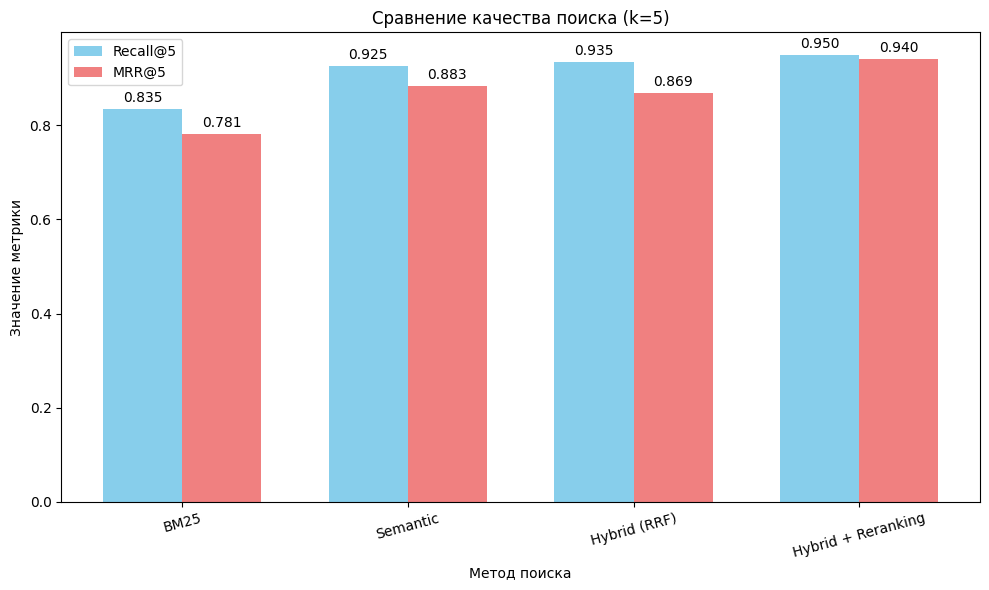

/tmp/ipykernel_1107/3316630200.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(methods, rotation=15)


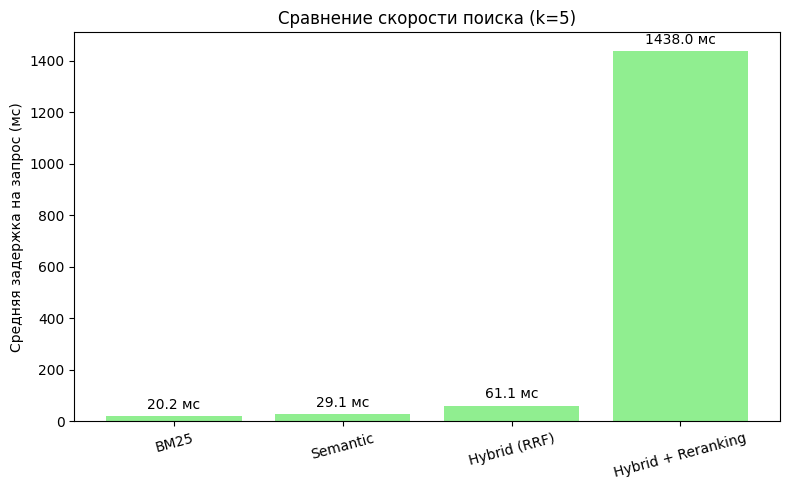

In [ ]:

# === ВАШ КОД ЗДЕСЬ ===
# 1. Сбор метрик (если не сохранены, запустите заново)
# bm25_metrics и semantic_metrics уже есть из задания 4
hybrid_metrics = evaluate_retriever(search_hybrid, test_queries, corpus, k=5)
rerank_metrics = evaluate_retriever(search_with_reranking, test_queries, corpus, k=5)

# 2. Создание DataFrame и вывод таблицы
import pandas as pd
metrics_df = pd.DataFrame({
    "Метод": ["BM25", "Semantic", "Hybrid (RRF)", "Hybrid + Reranking"],
    "Recall@5": [
        bm25_metrics["Recall@K"],
        semantic_metrics["Recall@K"],
        hybrid_metrics["Recall@K"],
        rerank_metrics["Recall@K"]
    ],
    "MRR@5": [
        bm25_metrics["MRR@K"],
        semantic_metrics["MRR@K"],
        hybrid_metrics["MRR@K"],
        rerank_metrics["MRR@K"]
    ],
    "Latency (ms)": [
        bm25_metrics["Latency_ms"],
        semantic_metrics["Latency_ms"],
        hybrid_metrics["Latency_ms"],
        rerank_metrics["Latency_ms"]
    ]
})
print("Сравнительная таблица метрик:")
print(metrics_df.to_string(index=False))

# 3. Визуализация качества (Recall и MRR)
import matplotlib.pyplot as plt
import numpy as np

methods = metrics_df["Метод"]
x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, metrics_df["Recall@5"], width, label='Recall@5', color='skyblue')
rects2 = ax.bar(x + width/2, metrics_df["MRR@5"], width, label='MRR@5', color='lightcoral')

ax.set_xlabel('Метод поиска')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение качества поиска (k=5)')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.legend()

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 4. Визуализация задержки
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, metrics_df["Latency (ms)"], color='lightgreen')
ax.set_ylabel('Средняя задержка на запрос (мс)')
ax.set_title('Сравнение скорости поиска (k=5)')
ax.set_xticklabels(methods, rotation=15)
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} мс',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')
plt.tight_layout()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===




### Вывод  в виде матрицы

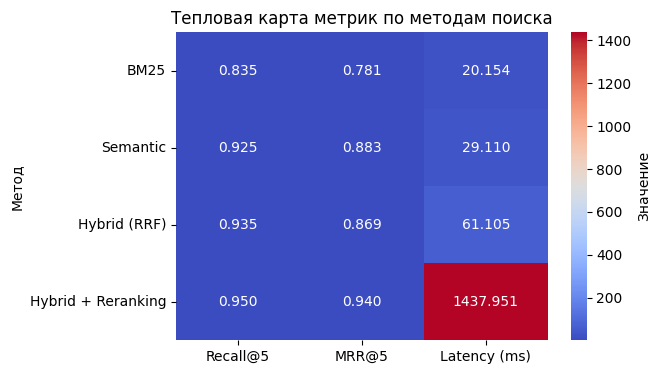

In [ ]:
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(metrics_df.set_index("Метод")[["Recall@5", "MRR@5", "Latency (ms)"]],
            annot=True, fmt=".3f", cmap="coolwarm", cbar_kws={'label': 'Значение'})
plt.title("Тепловая карта метрик по методам поиска")
plt.show()

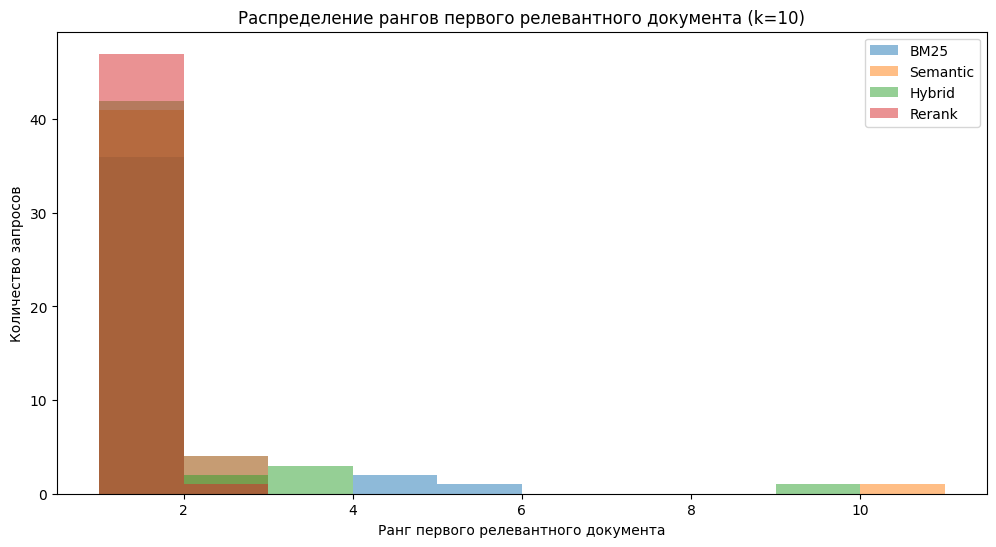

In [ ]:
def get_ranks(search_func, queries_data, corpus, k=10):
    ranks = []
    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()
        retrieved_ids = search_func(query, k=k)
        for rank, doc_id in enumerate(retrieved_ids, start=1):
            if ground_truth in corpus[doc_id].lower():
                ranks.append(rank)
                break
        else:
            ranks.append(None)  # не найден
    return ranks

# возьмём первые 50 запросов для скорости
sample_queries = test_queries[:50]
ranks_bm25 = get_ranks(search_bm25, sample_queries, corpus, k=10)
ranks_sem = get_ranks(search_semantic, sample_queries, corpus, k=10)
ranks_hyb = get_ranks(search_hybrid, sample_queries, corpus, k=10)
ranks_rer = get_ranks(search_with_reranking, sample_queries, corpus, k=10)

plt.figure(figsize=(12, 6))
plt.hist([r for r in ranks_bm25 if r is not None], bins=range(1,12), alpha=0.5, label='BM25')
plt.hist([r for r in ranks_sem if r is not None], bins=range(1,12), alpha=0.5, label='Semantic')
plt.hist([r for r in ranks_hyb if r is not None], bins=range(1,12), alpha=0.5, label='Hybrid')
plt.hist([r for r in ranks_rer if r is not None], bins=range(1,12), alpha=0.5, label='Rerank')
plt.xlabel('Ранг первого релевантного документа')
plt.ylabel('Количество запросов')
plt.title('Распределение рангов первого релевантного документа (k=10)')
plt.legend()
plt.show()

### Задание 11. Расширенная оценка стоимости запросов (5 баллов)

В продвинутом пайплайне мы используем переранжирование, что увеличивает время ответа, но как это влияет на стоимость LLM?
Само переранжирование (cross-encoder) работает локально и бесплатно. Значит, стоимость API LLM зависит только от финального K (количества документов, передаваемых в промпт).

**Что нужно сделать:**
1. Постройте график зависимости стоимости 1000 запросов от параметра K (от 1 до 10) при фиксированной длине ответа (например, 150 токенов).
2. Используйте функцию `estimate_cost` из Задания 6. Усредните длину документа по корпусу для расчетов.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
import matplotlib.pyplot as plt
import numpy as np

# берём ту же выборку, что и в задании 6 (первые 20 запросов)
sample_queries = test_queries[:20]
max_output_tokens = 150

# список K от 1 до 10
ks = list(range(1, 11))
costs_per_1000 = []

for k in ks:
    total_cost = 0.0
    for item in sample_queries:
        query = item['question']
        # получаем k документов через семантический поиск (можно заменить на гибридный)
        doc_ids = search_semantic(query, k=k)
        docs_texts = [corpus[doc_id] for doc_id in doc_ids]
        cost = estimate_cost(query, docs_texts, max_output_tokens)
        total_cost += cost
    avg_cost_per_query = total_cost / len(sample_queries)
    cost_per_1000 = avg_cost_per_query * 1000
    costs_per_1000.append(cost_per_1000)

# основной график
plt.figure(figsize=(8, 5))
plt.plot(ks, costs_per_1000, marker='o', linestyle='-', color='b', label=f'max_output_tokens={max_output_tokens}')
plt.xlabel('Количество документов (K)')
plt.ylabel('Стоимость 1000 запросов ($)')
plt.title('Зависимость стоимости от K при фиксированной длине ответа')
plt.grid(True)
plt.xticks(ks)
for x, y in zip(ks, costs_per_1000):
    plt.text(x, y + 0.02, f'{y:.3f}', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

# дополнительный график: сравнение для разных длин ответа
output_lengths = [50, 150, 300]
colors = ['green', 'blue', 'red']
plt.figure(figsize=(8, 5))
for max_tokens, color in zip(output_lengths, colors):
    costs = []
    for k in ks:
        total_cost = 0.0
        for item in sample_queries:
            query = item['question']
            doc_ids = search_semantic(query, k=k)
            docs_texts = [corpus[doc_id] for doc_id in doc_ids]
            cost = estimate_cost(query, docs_texts, max_tokens)
            total_cost += cost
        avg_cost = total_cost / len(sample_queries)
        costs.append(avg_cost * 1000)
    plt.plot(ks, costs, marker='o', linestyle='-', color=color, label=f'max_output_tokens={max_tokens}')
plt.xlabel('Количество документов (K)')
plt.ylabel('Стоимость 1000 запросов ($)')
plt.title('Сравнение стоимости для разных длин ответа')
plt.grid(True)
plt.xticks(ks)
plt.legend()
plt.tight_layout()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===

### Задание 12. Итоговые выводы (5 баллов)

Поздравляем с завершением практической части! Теперь проанализируйте полученные результаты.

**Что нужно сделать:**
Напишите развернутый вывод (3-4 абзаца) в markdown-ячейке ниже. Ответьте на вопросы:
1. Какой метод поиска показал лучшее качество на данном датасете и почему?
2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?
3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

---
*Пишите ваши выводы здесь...*


# **Итоговые выводы по проекту "ВикиПомощник"**

### 1. Какой метод поиска показал лучшее качество на данном датасете и почему?

Самый лучший метод поиска в моём эксперименте — это ***гибридный поиск с переранжированием***.
Он показал: самую высокую полноту (0.95) и среднюю позицию первого релевантного документа (0.94).

Это произошло потому, что он объединяет сильные стороны сразу двух подходов: BM25 - находит ***точные совпадения*** слов (имена, даты, термины), а семантический поиск- понимает ***смысл***. А переранжирование с помощью кросс-энкодера уже финально проверяет пару "запрос-документ" и ***выставляет самые релевантные наверх***.

### 2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?

- Я считаю, что оправдано с точки зрения баланса качество/скорость (latency), **если выполняет поставленную задачу**. Тут все зависит от того, какая у на цель.

- Да, долго идет поиск, но он и лучше. И если нам нужен более точный поиск, надо чемто пожертвовать.

- Я бы - рекомендовал использовать в следующих бизнес-кейсах:

1. Большие вычислительные системы. Например, системы, для анализа рынка, его течений, параметров акций, курсов и прочего.

2. Когда основной процес и без того занимает огромную кучу в ремени. Особенно если поиск я вляется частью процесса, а не оперативным собеседником с клиентом.

3. Качество важнее скорости. Например Прокуро ищет документ для суда. от этого зависит судьба виновного.


Но этот поиск не подходит для разговорного чат-бота для быстрых ответов, где важна мгновенная реакция. Тут лучше использовать обычный гибридный поиск без переранжирования.
Также может быть нерационально использовать этот поиск, если бюджет на сервера ограничен, потому что кросс-энкодер требует видеопамяти и вычислительных ресурсов.


### 3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

- Чем больше документов, тем выше стоимость запроса, т.к. бельше токенов, больше надо платить за токены.

- При этом, увеличение K дает более лучший ответ при нестондартном и сложном запросе на поиск. т.к. **Нужный файл** может буть не слишком идеально подходящим и быть на невысоком рейтинге

- Для моего "ВикиПомощника" (с моими ресурсами) я бы выбрал значение K = 3. Это даёт хорошее качество ответов (потому что модель видит несколько разных источников) и при этом не слишком дорого стоит.

- Если же финансирование другого менеджера позволяет и нужна максимальная точность, можно взять K = 5, но тогда каждый запрос будет стоить почти в два раза дороже, чем с тремя документами.

## Критерии оценки
- **Работоспособность кода:** Код выполняется без ошибок, пайплайны поиска и генерации функционируют корректно.
- **Корректность алгоритмов:** Верная реализация RRF, правильное использование FAISS и Cross-Encoder.
- **Качество визуализации:** Графики читаемы, имеют оси и легенду, таблица метрик наглядна.
- **Глубина анализа:** Выводы в задании 12 логичны, опираются на полученные цифры и бизнес-контекст.
- **Оформление:** Код структурирован, присутствуют комментарии на русском языке, соблюден академический стиль.
